In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Workflow

- Data Acquisition/Loading
- Initial EDA
- Data cleaning and preprocessing (feature data type, mapping, duplicated values, null values, outlier).
- Deeper EDA- summary statistic and visualisation
- Train-Test Split
- Data/Feature transformation (fit on train, transform on test) e.g. numerical transformation e.g. binning, scaling e.g. standardisation or normalisation, categorical/non-numerical encoding e.g. mapping, one-hot coding
- Feature selection (filter method e.g. collinearity, wrapper method, embedded method)
- Dimensionality reduction **(if necessary)**
- Model selection/building (on train dataset)
- Hyperparameter tuning (on validation dataset), e.g. grid search or random search
- Model Evaluation

# Data Loading

In [4]:
df = pd.read_csv("life_expectancy.csv")
df.head()

,Country,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life expectancy
0,Afghanistan,2015,Developing,263.0,62,0.01,71.279624,65.0,1154,19.1,...,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,65.0
1,Afghanistan,2014,Developing,271.0,64,0.01,73.523582,62.0,492,18.6,...,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,59.9
2,Afghanistan,2013,Developing,268.0,66,0.01,73.219243,64.0,430,18.1,...,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,59.9
3,Afghanistan,2012,Developing,272.0,69,0.01,78.184215,67.0,2787,17.6,...,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,59.5
4,Afghanistan,2011,Developing,275.0,71,0.01,7.097109,68.0,3013,17.2,...,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,59.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Adult Mortality                  2938 non-null   float64
 4   infant deaths                    2938 non-null   int64  
 5   Alcohol                          2938 non-null   float64
 6   percentage expenditure           2938 non-null   float64
 7   Hepatitis B                      2938 non-null   float64
 8   Measles                          2938 non-null   int64  
 9    BMI                             2938 non-null   float64
 10  under-five deaths                2938 non-null   int64  
 11  Polio                            2938 non-null   float64
 12  Total expenditure   

In [6]:
df.Status.value_counts()

Status
Developing    2426
Developed      512
Name: count, dtype: int64

In [7]:
df.isna().sum()

Country                            0
Year                               0
Status                             0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
Life expectancy                    0
dtype: int64

In [13]:
df.duplicated().sum()

0

# Initial EDA

### Univariate EDA

In [17]:
df.columns.tolist()

['Country',
 'Year',
 'Status',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles ',
 ' BMI ',
 'under-five deaths ',
 'Polio',
 'Total expenditure',
 'Diphtheria ',
 ' HIV/AIDS',
 'GDP',
 'Population',
 ' thinness  1-19 years',
 ' thinness 5-9 years',
 'Income composition of resources',
 'Schooling',
 'Life expectancy']

While attempting to plot the distribution of the numerical values, ' BMI ' was discovered to have both preceeding and trailing spaces which were then removed to ensure proper naming

In [20]:
df["BMI"] = df[" BMI "]
df["under_five_deaths"]= df["under-five deaths "]
df["Population"] = df["Population"]
df.head()

,Country,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life expectancy,BMI,under_five_deaths
0,Afghanistan,2015,Developing,263.0,62,0.01,71.279624,65.0,1154,19.1,...,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,65.0,19.1,83
1,Afghanistan,2014,Developing,271.0,64,0.01,73.523582,62.0,492,18.6,...,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,59.9,18.6,86
2,Afghanistan,2013,Developing,268.0,66,0.01,73.219243,64.0,430,18.1,...,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,59.9,18.1,89
3,Afghanistan,2012,Developing,272.0,69,0.01,78.184215,67.0,2787,17.6,...,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,59.5,17.6,93
4,Afghanistan,2011,Developing,275.0,71,0.01,7.097109,68.0,3013,17.2,...,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,59.2,17.2,97


# Preprocessing 

In [23]:
# Create GDP-per-capital
df["GDP_Per_Capita"] = df.GDP/df.Population
df["Expenditure_per_capita"] = df["percentage expenditure"]/df.Population
df.head()

,Country,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life expectancy,BMI,under_five_deaths,GDP_Per_Capita,Expenditure_per_capita
0,Afghanistan,2015,Developing,263.0,62,0.01,71.279624,65.0,1154,19.1,...,33736494.0,17.2,17.3,0.479,10.1,65.0,19.1,83,0.000017,0.000002
1,Afghanistan,2014,Developing,271.0,64,0.01,73.523582,62.0,492,18.6,...,327582.0,17.5,17.5,0.476,10.0,59.9,18.6,86,0.001870,0.000224
2,Afghanistan,2013,Developing,268.0,66,0.01,73.219243,64.0,430,18.1,...,31731688.0,17.7,17.7,0.470,9.9,59.9,18.1,89,0.000020,0.000002
3,Afghanistan,2012,Developing,272.0,69,0.01,78.184215,67.0,2787,17.6,...,3696958.0,17.9,18.0,0.463,9.8,59.5,17.6,93,0.000181,0.000021
4,Afghanistan,2011,Developing,275.0,71,0.01,7.097109,68.0,3013,17.2,...,2978599.0,18.2,18.2,0.454,9.5,59.2,17.2,97,0.000021,0.000002


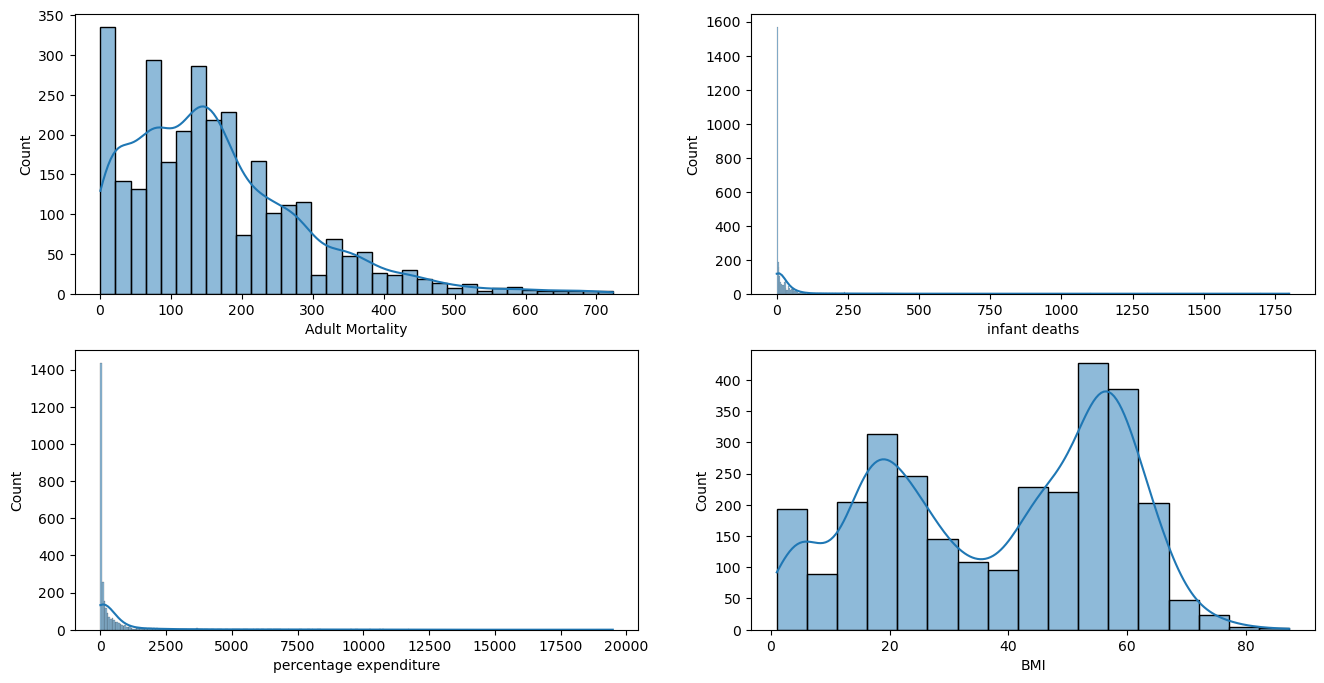

In [25]:
# Diplay the Distribution of Numerical Variables
fig, ax = plt.subplots(2,2,figsize=(16,8))
sns.histplot(df, x= "Adult Mortality", kde=True, ax=ax[0,0])
sns.histplot(df, x= "infant deaths", kde=True, ax=ax[0,1])
sns.histplot(df, x= "percentage expenditure", kde=True, ax=ax[1,0])
sns.histplot(df, x= "BMI", kde=True, ax=ax[1,1])
plt.show()

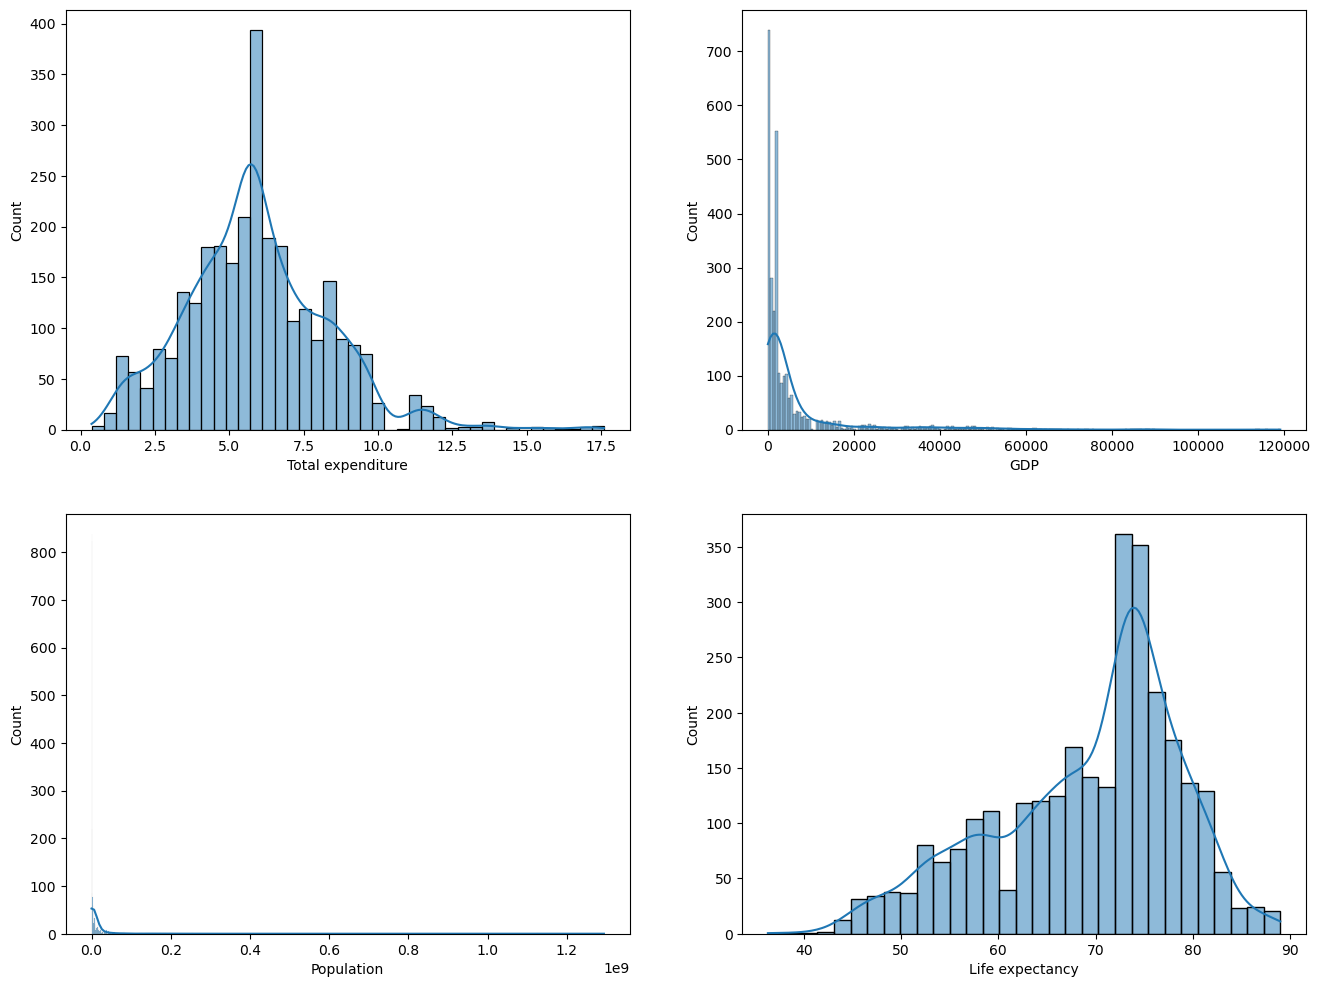

In [26]:
fig, ax = plt.subplots(2,2,figsize=(16,12))
sns.histplot(df, x= "Total expenditure", kde=True, ax=ax[0,0])
sns.histplot(df, x= "GDP", kde=True, ax=ax[0,1])
sns.histplot(df, x= "Population", kde=True, ax=ax[1,0])
sns.histplot(df, x= "Life expectancy", kde=True, ax=ax[1,1])
plt.show()

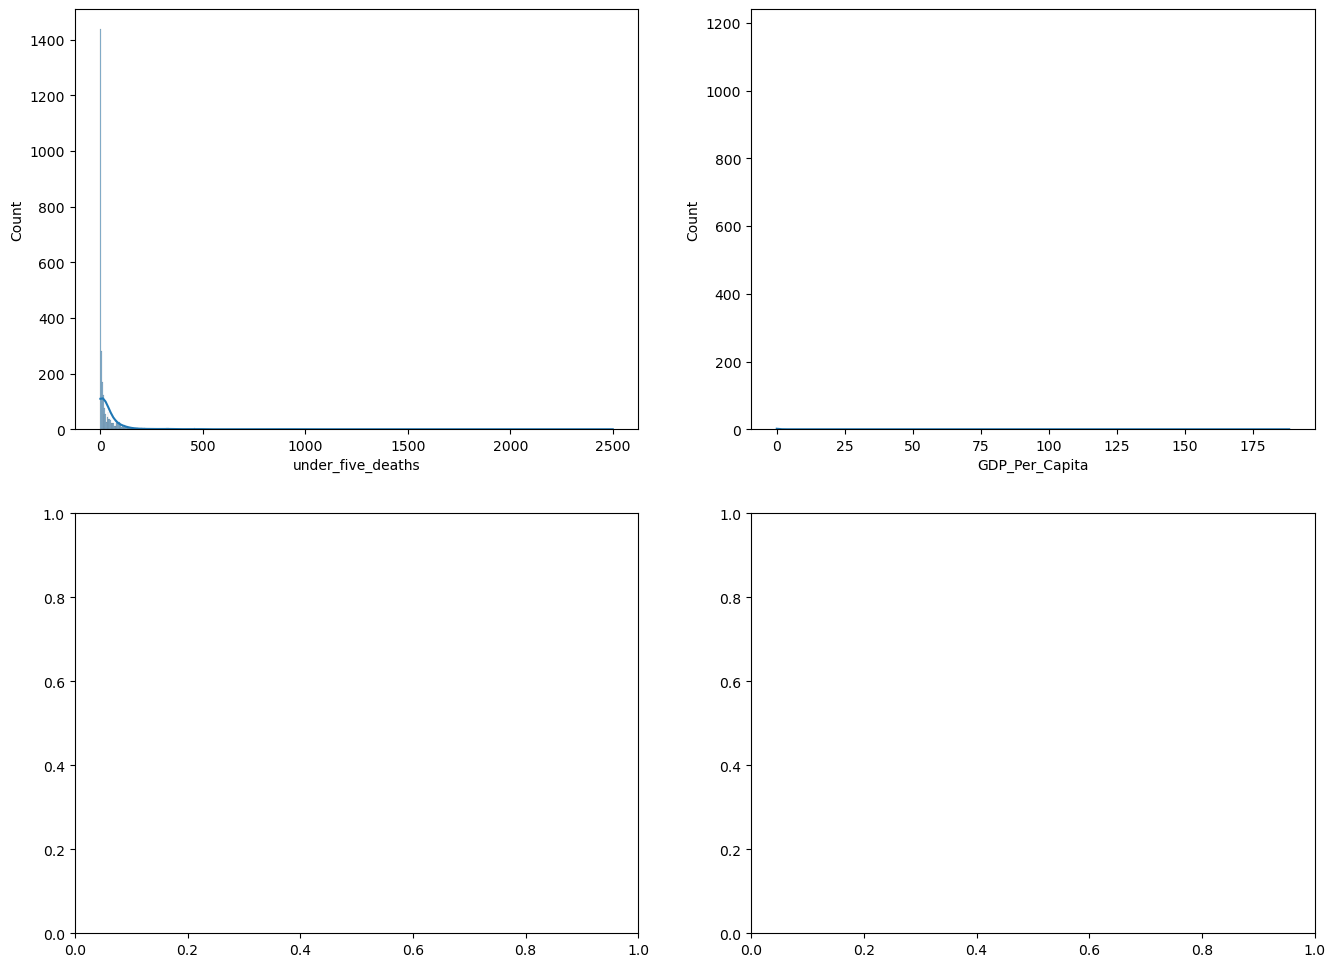

In [27]:
fig, ax = plt.subplots(2,2,figsize=(16,12))
sns.histplot(df, x= "under_five_deaths", kde=True, ax=ax[0,0])
#sns.histplot(df, x= "GDP_Per_Capita", kde=True, ax=ax[0,1])
#sns.histplot(df, x= "Expenditure_per_capita", kde=True, ax=ax[1,0])
plt.show()

In [31]:
print("Adult Mortality skewness: ", df["Adult Mortality"].skew()) 
print("infant deaths skewness: ", df["infant deaths"].skew()) 
print("percentage expenditure skewness: ", df["percentage expenditure"].skew()) 
print("BMI skewness: ", df["BMI"].skew()) 
print("Total expenditure skewness: ", df["Total expenditure"].skew()) 
print("GDP skewness: ", df["GDP"].skew()) 
print("Population skewness: ", df["Population"].skew()) 
print("Life expectancy skewness: ", df["Life expectancy"].skew()) 
print("under_five_deaths skewness: ", df["under_five_deaths"].skew()) 
print("GDP_Per_Capita skewness: ", df["GDP_Per_Capita"].skew()) 

Adult Mortality skewness:  1.1778994205802995
infant deaths skewness:  9.786962950426057
percentage expenditure skewness:  4.652051347835061
BMI skewness:  -0.22915683845939586
Total expenditure skewness:  0.6611082208136568
GDP skewness:  3.543755873452576
Population skewness:  17.972837117060475
Life expectancy skewness:  -0.642390808653847
under_five_deaths skewness:  9.495064656961773
GDP_Per_Capita skewness:  31.9132292489845


### check for outliers

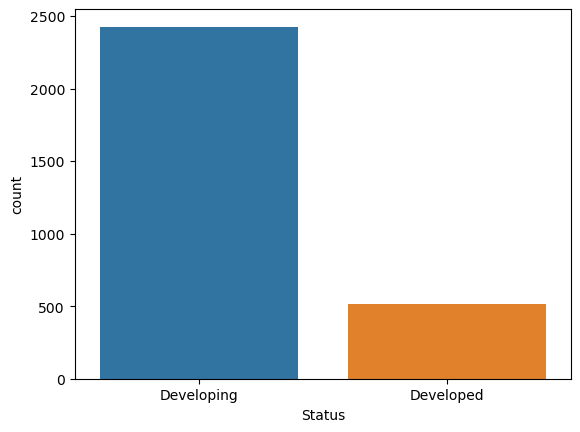

In [34]:
# plot the distribution of country
sns.countplot(df, x="Status", hue="Status")
plt.show()

### Bivariate EDA

In [37]:
gdp_by_year = df[["Year", "GDP"]].groupby("Year").mean()
gdp_by_year.head()

,GDP
Year,
2000,4242.365135
2001,4382.111020
2002,4165.937182
2003,4314.612364
2004,6275.553987


In [39]:
gdp_percapita_by_year = df[["Year", "GDP_Per_Capita"]].groupby("Year").mean()
gdp_percapita_by_year.head()

,GDP_Per_Capita
Year,
2000,0.135425
2001,0.097075
2002,0.192628
2003,0.604775
2004,0.488384


In [41]:
percentage_expenditure_by_year = df[["Year", "percentage expenditure"]].groupby("Year").mean()
percentage_expenditure_by_year.head()

,percentage expenditure
Year,
2000,473.850781
2001,516.625910
2002,476.794487
2003,494.706547
2004,772.336156


In [43]:
percentage_exp_percapita_by_year = df[["Year", "Expenditure_per_capita"]].groupby("Year").mean()
percentage_exp_percapita_by_year.head()

,Expenditure_per_capita
Year,
2000,0.020392
2001,0.012164
2002,0.017837
2003,0.084798
2004,0.058154


In [83]:
population_by_year = df[["Year", "Population"]].groupby("Year").mean()
population_by_year.head()

,Population
Year,
2000,7.680028e+06
2001,8.172421e+06
2002,5.480238e+06
2003,8.242208e+06
2004,1.347235e+07


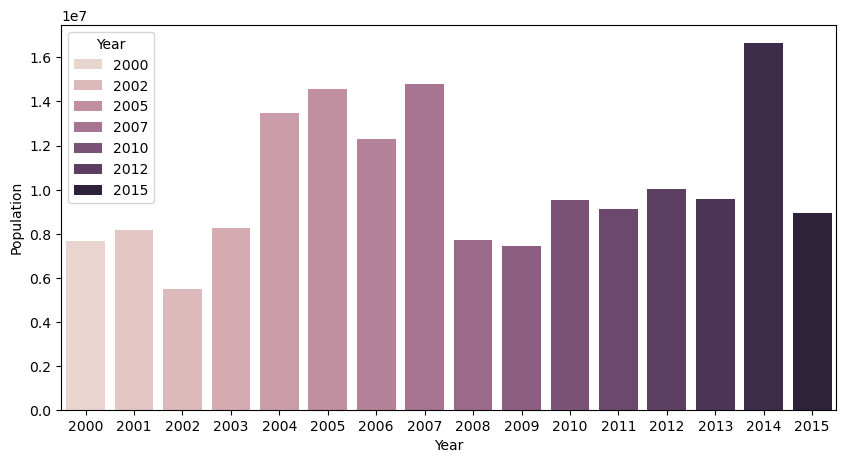

In [91]:
fig,ax = plt.subplots(figsize=(10,5))
sns.barplot(population_by_year, x="Year", y="Population", hue = "Year")
plt.show()

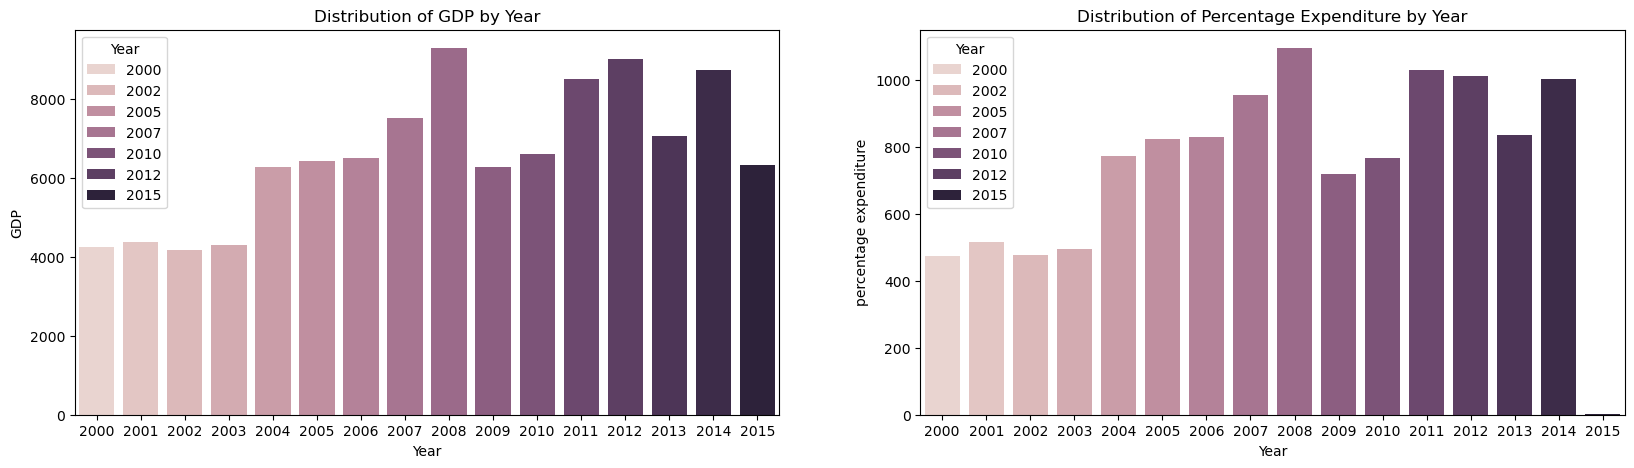

In [47]:
fig,ax = plt.subplots(1, 2,figsize=(20,5))
sns.barplot(gdp_by_year, x= "Year", y ="GDP", hue="Year", ax=ax[0])
ax[0].set_title("Distribution of GDP by Year")
sns.barplot(percentage_expenditure_by_year, x= "Year", y ="percentage expenditure", hue="Year", ax=ax[1])
ax[1].set_title("Distribution of Percentage Expenditure by Year")
plt.show()

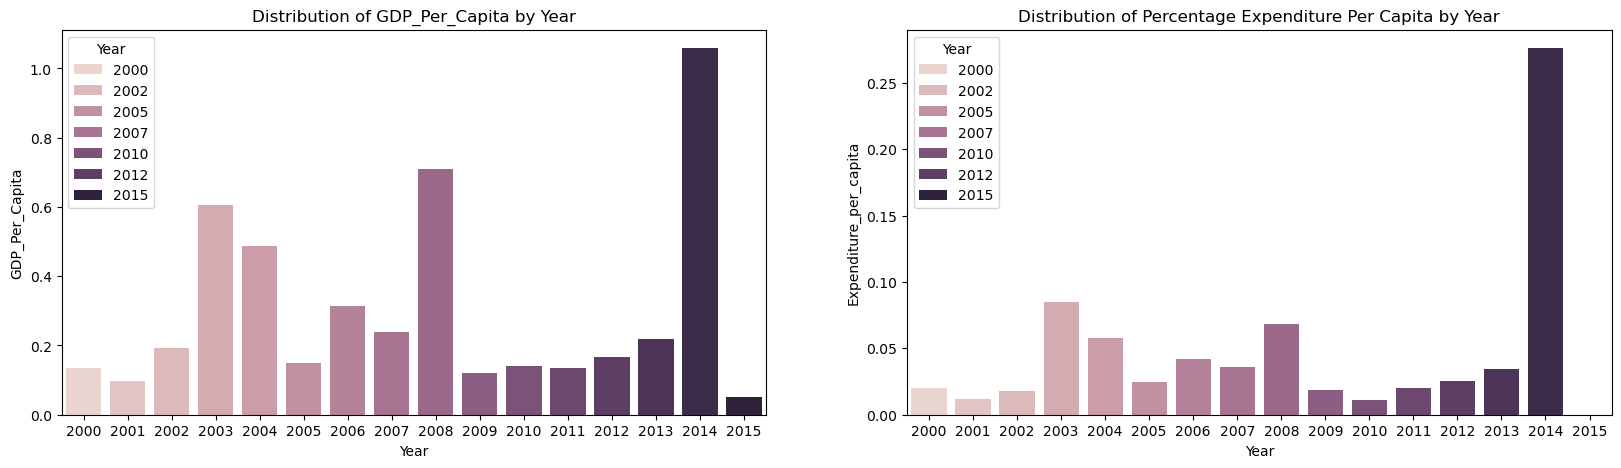

In [49]:
fig,ax = plt.subplots(1, 2,figsize=(20,5))
sns.barplot(gdp_percapita_by_year, x= "Year", y ="GDP_Per_Capita", hue="Year", ax=ax[0])
ax[0].set_title("Distribution of GDP_Per_Capita by Year")
sns.barplot(percentage_exp_percapita_by_year, x= "Year", y ="Expenditure_per_capita", hue="Year", ax=ax[1])
ax[1].set_title("Distribution of Percentage Expenditure Per Capita by Year")
plt.show()

In [51]:
gdp_by_status = df[["Status", "GDP"]].groupby("Status").mean()
gdp_by_status

,GDP
Status,
Developed,19517.581590
Developing,3887.739215


In [53]:
gdp_percapita_by_status = df[["Status", "GDP_Per_Capita"]].groupby("Status").mean()
gdp_percapita_by_status

,GDP_Per_Capita
Status,
Developed,0.357309
Developing,0.288933


In [55]:
LE_by_status = df[["Status", "Life expectancy"]].groupby("Status").mean()
LE_by_status

,Life expectancy
Status,
Developed,79.197852
Developing,67.132028


In [57]:
population_by_status = df[["Status", "Population"]].groupby("Status").mean()
population_by_status

,Population
Status,
Developed,5.809395e+06
Developing,1.116399e+07


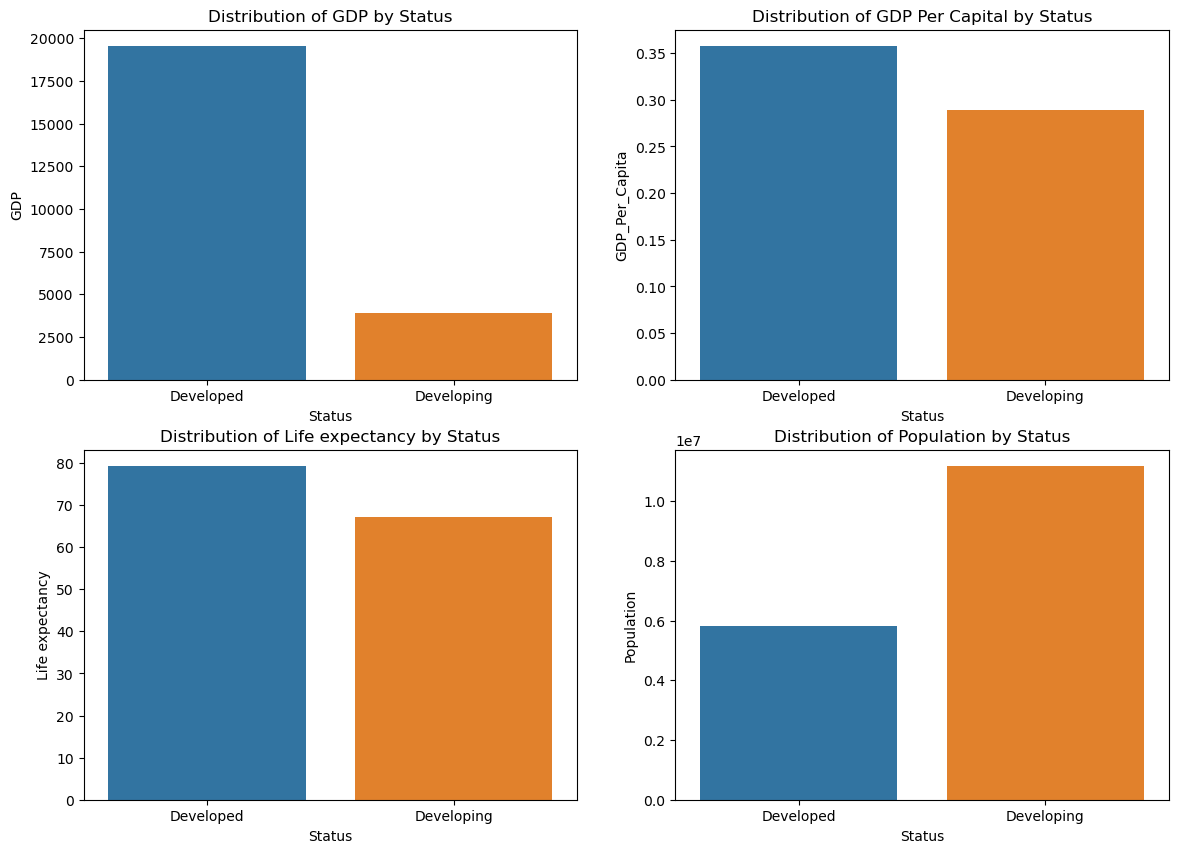

In [59]:
fig, ax = plt.subplots(2,2,figsize=(14,10))
sns.barplot(gdp_by_status, x = "Status", y="GDP" , hue ="Status", ax=ax[0,0])
sns.barplot(gdp_percapita_by_status, x = "Status", y= "GDP_Per_Capita", hue ="Status", ax=ax[0,1])
sns.barplot(LE_by_status, x = "Status", y="Life expectancy" , hue ="Status", ax=ax[1,0])
sns.barplot(population_by_status, x = "Status", y= "Population", hue ="Status", ax=ax[1,1])
ax[0,0].set_title("Distribution of GDP by Status")
ax[0,1].set_title("Distribution of GDP Per Capital by Status")
ax[1,0].set_title("Distribution of Life expectancy by Status")
ax[1,1].set_title("Distribution of Population by Status")
plt.show()

### Multivariate EDA

In [62]:
population_by_year_and_status = df[["Year", "Status", "Population"]].groupby(["Year", "Status"]).mean()
population_by_year_and_status.head()

Population
Year Status                  
2000 Developed   3.788473e+06
     Developing  8.504728e+06
2001 Developed   3.906444e+06
     Developing  9.076470e+06
2002 Developed   6.227871e+06

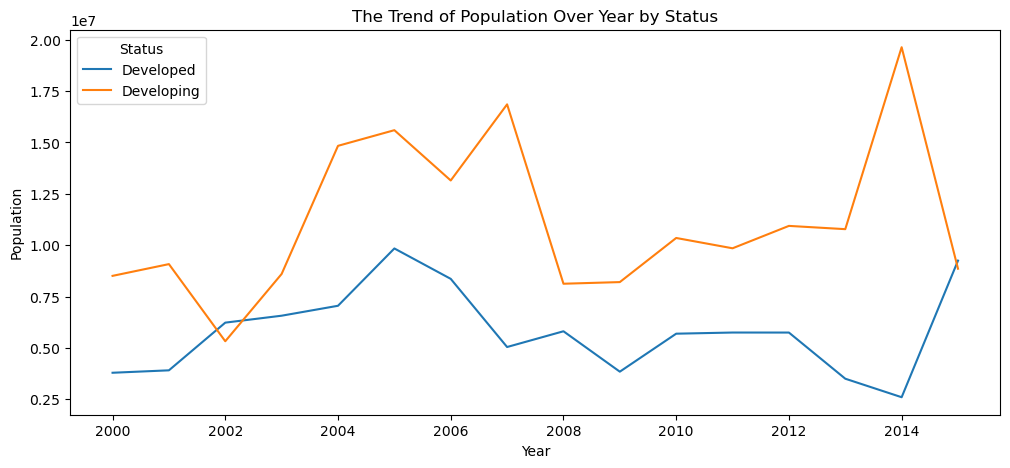

In [79]:
fig = plt.figure(figsize=(12,5))
sns.lineplot(population_by_year_and_status, x="Year", y="Population", hue="Status")
plt.title("The Trend of Population Over Year by Status")
plt.show()

In [93]:
gdgpc_pop_le_by_year = df[["Year", "Population", "GDP_Per_Capita", "Life expectancy", "percentage expenditure"]].groupby("Year").mean()
gdgpc_pop_le_by_year.head()

,Population,GDP_Per_Capita,Life expectancy,percentage expenditure
Year,,,,
2000,7.680028e+06,0.135425,66.750273,473.850781
2001,8.172421e+06,0.097075,67.128962,516.625910
2002,5.480238e+06,0.192628,67.351366,476.794487
2003,8.242208e+06,0.604775,67.433333,494.706547
2004,1.347235e+07,0.488384,67.646448,772.336156


In [95]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
gdgpc_pop_le_by_year[["Population", "GDP_Per_Capita", "Life expectancy", "percentage expenditure"]] = scaler.fit_transform(
    gdgpc_pop_le_by_year[["Population", "GDP_Per_Capita", "Life expectancy", "percentage expenditure"]])

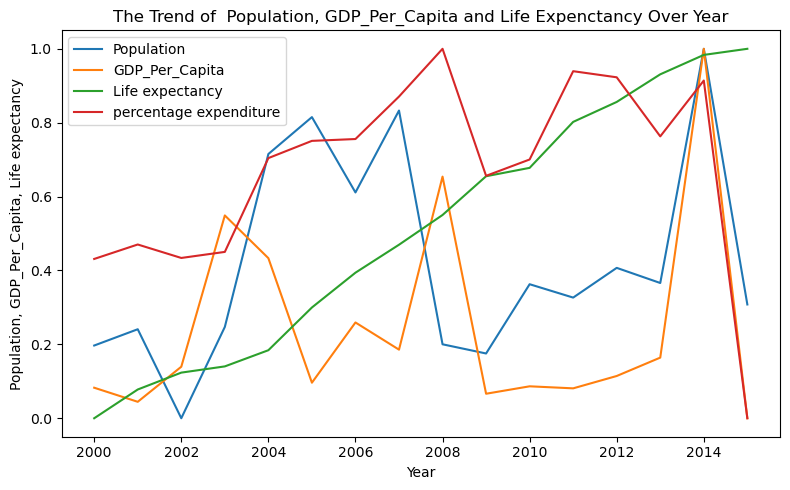

In [97]:
fig = plt.figure(figsize=(8,5))
plt.plot(gdgpc_pop_le_by_year.index, gdgpc_pop_le_by_year["Population"])
plt.plot(gdgpc_pop_le_by_year.index, gdgpc_pop_le_by_year["GDP_Per_Capita"])
plt.plot(gdgpc_pop_le_by_year.index, gdgpc_pop_le_by_year["Life expectancy"])
plt.plot(gdgpc_pop_le_by_year.index, gdgpc_pop_le_by_year["percentage expenditure"])
plt.xlabel("Year")
plt.ylabel("Population, GDP_Per_Capita, Life expectancy")
plt.title("The Trend of  Population, GDP_Per_Capita and Life Expenctancy Over Year")
plt.legend(["Population", "GDP_Per_Capita", "Life expectancy", "percentage expenditure"])
plt.tight_layout()
plt.show()

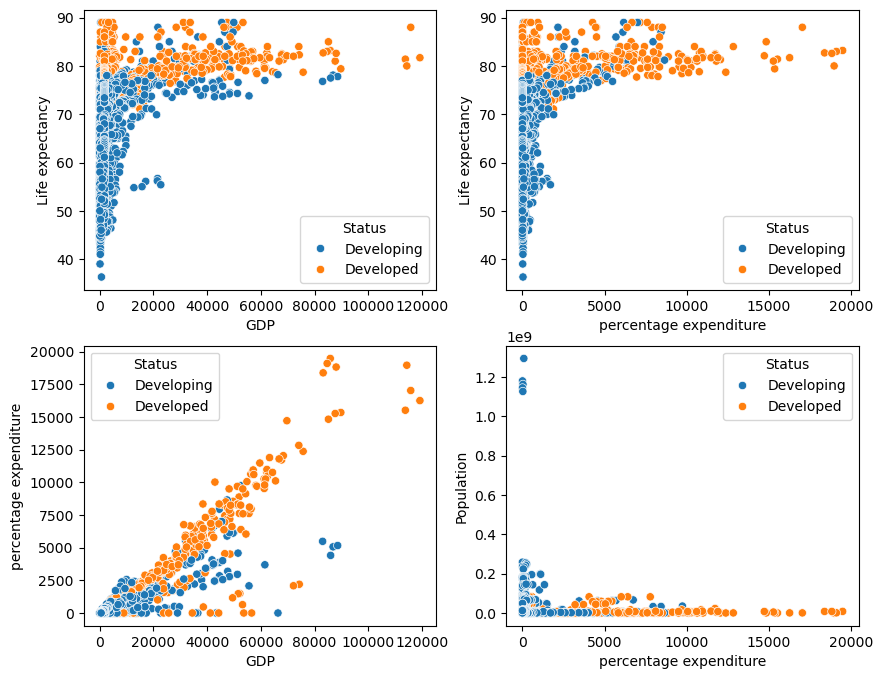

In [99]:
fig,ax = plt.subplots(2,2,figsize=(10,8))
sns.scatterplot(df, x=df.GDP, y=df["Life expectancy"], hue="Status", ax=ax[0,0])
sns.scatterplot(df, x=df["percentage expenditure"], y=df["Life expectancy"], hue="Status", ax=ax[0,1])
sns.scatterplot(df, x=df["GDP"], y=df["percentage expenditure"], hue="Status", ax=ax[1,0])
sns.scatterplot(df, x=df["percentage expenditure"], y=df["Population"], hue="Status", ax=ax[1,1])
plt.show()

# Feature Engineering

In [102]:
# Create X and y
X = df.drop(columns = ["Country", "Life expectancy", "Year"])
y = df["Life expectancy"]
y.head()

0    65.0
1    59.9
2    59.9
3    59.5
4    59.2
Name: Life expectancy, dtype: float64

In [104]:
# Perform Hot Coding on Status 
X = pd.get_dummies(X, columns = ["Status"], drop_first = False)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Adult Mortality                  2938 non-null   float64
 1   infant deaths                    2938 non-null   int64  
 2   Alcohol                          2938 non-null   float64
 3   percentage expenditure           2938 non-null   float64
 4   Hepatitis B                      2938 non-null   float64
 5   Measles                          2938 non-null   int64  
 6    BMI                             2938 non-null   float64
 7   under-five deaths                2938 non-null   int64  
 8   Polio                            2938 non-null   float64
 9   Total expenditure                2938 non-null   float64
 10  Diphtheria                       2938 non-null   float64
 11   HIV/AIDS                        2938 non-null   float64
 12  GDP                 

In [106]:
# Standardise X
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
# Standardise X
scaler = StandardScaler()
X_train_stand =scaler.fit_transform(X_train)
X_test_stand = scaler.transform(X_test)

### Build a Dummy Model for Baseline Evaluation

In [109]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error
reg_dummy = DummyRegressor(strategy = "mean") # you can also use median depending on the dataset
reg_dummy.fit(X_train_stand, y_train)
y_pred_dummy = reg_dummy.predict(X_test_stand)
baseline_MAE = mean_absolute_error(y_test, y_pred_dummy)
print("Baseline MAE is: ", baseline_MAE)

Baseline MAE is:  7.744579881239135


# Build the Model

In [112]:
# import the libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
# Build the model
def nn_model(X_train_stand):
    seq = Sequential()
    #add import layer
    feature_num = X_train_stand.shape[1]
    model_input = InputLayer(shape=(feature_num,))
    # Add input layer
    seq.add(model_input)
    # Add hidden layers
    seq.add(Dense(128, activation="relu"))
    # Add output layer
    seq.add(Dense(1))
    # Add optimisation layer
    # Add optimiser
    opt = Adam(learning_rate = 0.01)
    seq.compile(loss="mse", metrics=["mae"], optimizer=opt)
    return seq
seq = nn_model(X_train_stand)
seq.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [113]:
# Fit the data
seq.fit(X_train_stand, y_train, epochs = 40, batch_size=1, verbose=1, validation_split=0.2)
mse,mae = seq.evaluate(X_test_stand, y_test, verbose=0)
print("MSE is: ", mse)
print("MAE is: ", mae)

Epoch 1/40
1644/1644 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 644.1129 - mae: 15.5821 - val_loss: 33.3836 - val_mae: 4.2723
Epoch 2/40
1644/1644 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 42.1046 - mae: 4.2507 - val_loss: 27.0956 - val_mae: 3.8980
Epoch 3/40
1644/1644 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 55.9799 - mae: 4.3229 - val_loss: 21.3292 - val_mae: 3.1835
Epoch 4/40
1644/1644 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 29.4029 - mae: 3.5564 - val_loss: 18.7421 - val_mae: 3.1303
Epoch 5/40
1644/1644 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 56.9509 - mae: 4.3629 - val_loss: 25.6255 - val_mae: 3.3634
Epoch 6/40
1644/1644 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 46.4232 - mae: 4.1750 - val_loss: 20.3718 - val_mae: 3.5630
Epoch 7/40
1644/1644 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 14.7751 - mae: 2.9350 - val_loss: 136.0746 - val_mae: 7.8614
Epoch 8/40
1644/1644 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 42.3377 - mae: 4.5591 - val_loss: 38.3411 - val_mae: 4.0250
Epoch 9/40
1644/1644

In [ ]:
### Manual Hyperparameter Tunning